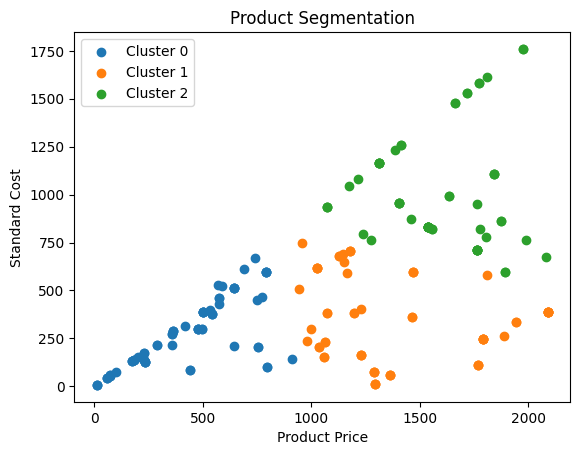

In [6]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Load data
data = pd.read_excel(r"C:\Users\sudhi\Desktop\Reasearch_dataset\ecommerce_data.xlsx")

# Clean columns
data.columns = data.columns.str.strip().str.lower()

# Convert numeric
data['product_price'] = pd.to_numeric(data['product_price'], errors='coerce')
data['standerd_price'] = pd.to_numeric(data['standerd_price'], errors='coerce')

# Features
X = data[['product_price', 'standerd_price']].dropna()

# KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
data.loc[X.index, 'cluster'] = kmeans.fit_predict(X)

# Plot
plt.figure()

for i in range(3):
    cluster_data = data[data['cluster'] == i]
    plt.scatter(cluster_data['product_price'], cluster_data['standerd_price'], label=f'Cluster {i}')

plt.xlabel("Product Price")
plt.ylabel("Standard Cost")
plt.title("Product Segmentation")

plt.legend()
plt.show()